<a href="https://colab.research.google.com/github/Mateus-Kent/Mateus-Kent/blob/main/analaise_explotoria_aula02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## O que é o IDHM

Links importantes<br/>
https://www.undp.org/pt/brazil/o-que-%C3%A9-o-idhm<br/>
Base de dados Ipea<br/>
https://www.ipea.gov.br/ipeageo/arquivos/bases/IDH_2010.xls

O Índice de Desenvolvimento Humano Municipal (IDHM) é uma medida composta de indicadores de três dimensões do desenvolvimento humano: longevidade, educação e renda. O índice varia de 0 a 1. Quanto mais próximo de 1, maior o desenvolvimento humano.

O IDHM brasileiro segue as mesmas três dimensões do IDH Global - longevidade, educação e renda, mas vai além: adequa a metodologia global ao contexto brasileiro e à disponibilidade de indicadores nacionais. Embora meçam os mesmos fenômenos, os indicadores levados em conta no IDHM são mais adequados para avaliar o desenvolvimento dos municípios brasileiros. Assim, o IDHM - incluindo seus três componentes, IDHM Longevidade, IDHM Educação e IDHM Renda - conta um pouco da história dos municípios em três importantes dimensões do desenvolvimento humano durantes duas décadas da história brasileira.

Pergunta Norteadora: "Quais são os Estados que possuem um bom IDH para que possamos entregar bons produtos."

In [46]:
#Libs

import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [47]:
idhm = pd.read_excel('https://docs.google.com/spreadsheets/d/1Dz4NAFFHCseE07WUAweVo9kKI9Krrez6/export?format=xlsx')
idhm.head()

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716
2,2010,11,Rondônia,110003,CABIXI,70.39,2.15,24.8,26.58,48.12,...,381,4306,6303,6156,0.357,0.700,0.650,0.559,0.757,0.650
3,2010,11,Rondônia,110004,CACOAL,74.27,1.90,14.3,15.38,43.79,...,4547,54356,78141,76876,0.488,0.698,0.718,0.620,0.821,0.727
4,2010,11,Rondônia,110005,CEREJEIRAS,72.94,2.12,18.1,19.42,45.67,...,1033,11786,16942,16815,0.430,0.712,0.692,0.602,0.799,0.688


Tamanho da Base de Dados

In [48]:
idhm.shape

(5564, 237)

In [49]:
print(f'Tamanho do nosso Dataset (Linhas, Colunas): {idhm.shape}')

Tamanho do nosso Dataset (Linhas, Colunas): (5564, 237)


Verificar os tipos do Dados

In [50]:
idhm.dtypes

,0
ANO,int64
Código da Unidade da Federação,int64
Nome da Unidade da Federação,object
Código do Município,int64
Município,object
...,...
Subíndice de frequência escolar - IDHM Educação,float64
IDHM,float64
IDHM Educação,float64
IDHM Longevidade,float64


Existe valores nulos?

In [51]:
idhm.isnull().sum().sum()

np.int64(0)

In [52]:
print(f'Quantidade de dados nulos no nosso dataframe (base de dados): {idhm.isnull().sum().sum()}')

Quantidade de dados nulos no nosso dataframe (base de dados): 0


Quais informações queremos trabalhar?

In [53]:
idhm.head(2)

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716


In [54]:
idhm.columns

Index(['ANO', 'Código da Unidade da Federação', 'Nome da Unidade da Federação',
       'Código do Município', 'Município', 'Esperança de vida ao nascer',
       'Taxa de fecundidade total', 'Mortalidade infantil',
       'Mortalidade até 5 anos de idade', 'Razão de dependência',
       ...
       'População de 15 a 17 anos.1', 'População de 18 anos ou mais.1',
       'População total em domicílios particulares permanentes',
       'População total em domicílios particulares permanentes, exceto com renda nula',
       'Subíndice de escolaridade - IDHM Educação',
       'Subíndice de frequência escolar - IDHM Educação', 'IDHM',
       'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda'],
      dtype='object', length=237)

In [55]:
exemplo = idhm[['Município','IDHM']]
exemplo.head()

,Município,IDHM
0,ALTA FLORESTA D'OESTE,0.641
1,ARIQUEMES,0.702
2,CABIXI,0.650
3,CACOAL,0.718
4,CEREJEIRAS,0.692


In [56]:
df_idhm = idhm[['Nome da Unidade da Federação', 'Município', 'IDHM', 'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda']]

In [57]:
df_idhm.head()

,Nome da Unidade da Federação,Município,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688


In [58]:
df_idhm.tail()

,Nome da Unidade da Federação,Município,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
5559,Goiás,VIANÓPOLIS,0.712,0.622,0.818,0.710
5560,Goiás,VICENTINÓPOLIS,0.684,0.562,0.804,0.707
5561,Goiás,VILA BOA,0.647,0.534,0.818,0.619
5562,Goiás,VILA PROPÍCIO,0.634,0.505,0.802,0.629
5563,Distrito Federal,BRASÍLIA,0.824,0.742,0.873,0.863


In [59]:
df_idhm.columns = ['uf', 'municipio', 'idhm', 'idhm_educacao', 'idhm_longevidade', 'idhm_renda']

In [60]:
df_idhm.head()

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688


Informações da Base

In [61]:
df_idhm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5564 entries, 0 to 5563
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uf                5564 non-null   object 
 1   municipio         5564 non-null   object 
 2   idhm              5564 non-null   float64
 3   idhm_educacao     5564 non-null   float64
 4   idhm_longevidade  5564 non-null   float64
 5   idhm_renda        5564 non-null   float64
dtypes: float64(4), object(2)
memory usage: 260.9+ KB


Valores únicos

In [62]:
df_idhm.nunique()

,0
uf,27
municipio,5329
idhm,349
idhm_educacao,466
idhm_longevidade,220
idhm_renda,390


Estatistica Descritiva

In [63]:
df_idhm.describe().round(2)

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.00,5564.00,5564.00,5564.00
mean,0.66,0.56,0.80,0.64
std,0.07,0.09,0.04,0.08
min,0.42,0.21,0.67,0.40
25%,0.60,0.49,0.77,0.57
50%,0.66,0.56,0.81,0.65
75%,0.72,0.63,0.84,0.71
max,0.86,0.82,0.89,0.89


## Classificação IDHM:

0 - 0,499 - Baixo Desenvolvimento Humano<br/>
0,5 - 0,799 - Médio Desenvolvimento Humano<br/>
0,8 - 1 - Alto Desenvolvimento Humano

In [64]:
df_idhm['idhm']

,idhm
0,0.641
1,0.702
2,0.650
3,0.718
4,0.692
...,...
5559,0.712
5560,0.684
5561,0.647
5562,0.634


In [65]:
# Função Classificação IDHM

def idhm_class(df):
   if df['idhm'] <= 0.499:
      return 'Baixo desenvolvimento Humano'
   elif df['idhm'] >= 0.8:
       return 'Alto desenvolvimento Humano'
   else:
      return 'Médio desenvolvimento Humano'

In [66]:
## C0nseguimos fazer uma coluna qualitativa com os valores do proprio IDHM

df_idhm['classe'] = df_idhm.apply(idhm_class, axis=1)
df_idhm

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classe
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Médio desenvolvimento Humano
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Médio desenvolvimento Humano
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Médio desenvolvimento Humano
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Médio desenvolvimento Humano
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Médio desenvolvimento Humano
...,...,...,...,...,...,...,...
5559,Goiás,VIANÓPOLIS,0.712,0.622,0.818,0.710,Médio desenvolvimento Humano
5560,Goiás,VICENTINÓPOLIS,0.684,0.562,0.804,0.707,Médio desenvolvimento Humano
5561,Goiás,VILA BOA,0.647,0.534,0.818,0.619,Médio desenvolvimento Humano
5562,Goiás,VILA PROPÍCIO,0.634,0.505,0.802,0.629,Médio desenvolvimento Humano


In [67]:
df_idhm.head(20)

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,classe
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Médio desenvolvimento Humano
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Médio desenvolvimento Humano
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Médio desenvolvimento Humano
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Médio desenvolvimento Humano
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Médio desenvolvimento Humano
5,Rondônia,COLORADO DO OESTE,0.685,0.584,0.814,0.676,Médio desenvolvimento Humano
6,Rondônia,CORUMBIARA,0.613,0.473,0.774,0.630,Médio desenvolvimento Humano
7,Rondônia,COSTA MARQUES,0.611,0.493,0.751,0.616,Médio desenvolvimento Humano
8,Rondônia,ESPIGÃO D'OESTE,0.672,0.536,0.819,0.691,Médio desenvolvimento Humano
9,Rondônia,GUAJARÁ-MIRIM,0.657,0.519,0.823,0.663,Médio desenvolvimento Humano


In [68]:
df_idhm['classe'].value_counts()

,count
classe,
Médio desenvolvimento Humano,5488
Alto desenvolvimento Humano,44
Baixo desenvolvimento Humano,32


Pairplot

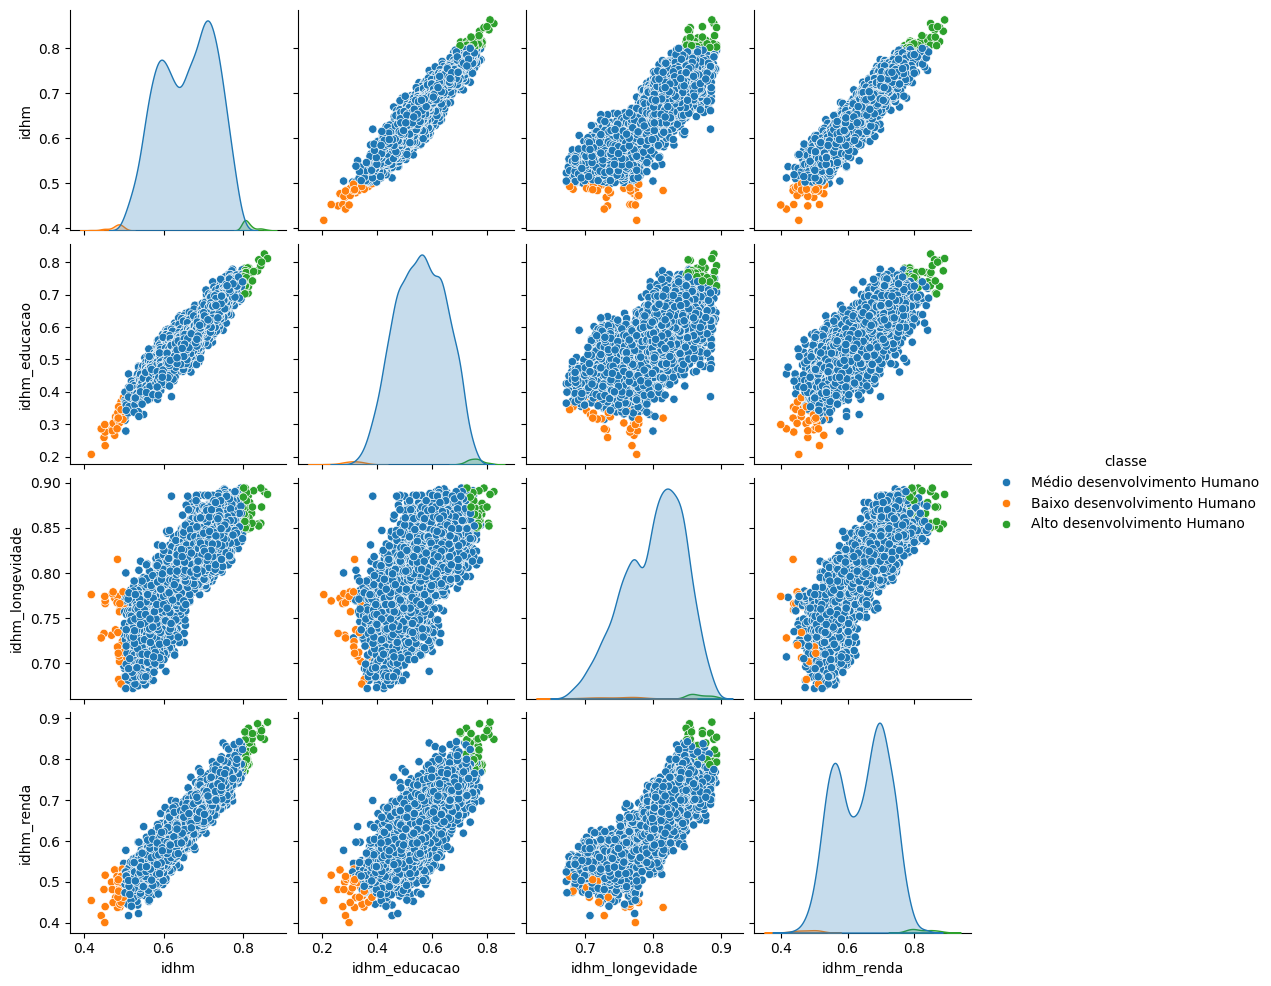

In [69]:
sns.pairplot(df_idhm, hue='classe')

Interessante a relação entre a renda e a escolaridade, parece ter relação

### Análise por estado

In [70]:
df_idhm_estado = pd.DataFrame(df_idhm.groupby('uf')['idhm'].mean().round(2)).reset_index()
df_idhm_estado

,uf,idhm
0,Acre,0.59
1,Alagoas,0.56
2,Amapá,0.64
3,Amazonas,0.57
4,Bahia,0.59
5,Ceará,0.62
6,Distrito Federal,0.82
7,Espírito Santo,0.69
8,Goiás,0.69
9,Maranhão,0.58


In [71]:
df_idhm_estado['classe'] = df_idhm_estado.apply(idhm_class, axis=1)
df_idhm_estado


,uf,idhm,classe
0,Acre,0.59,Médio desenvolvimento Humano
1,Alagoas,0.56,Médio desenvolvimento Humano
2,Amapá,0.64,Médio desenvolvimento Humano
3,Amazonas,0.57,Médio desenvolvimento Humano
4,Bahia,0.59,Médio desenvolvimento Humano
5,Ceará,0.62,Médio desenvolvimento Humano
6,Distrito Federal,0.82,Alto desenvolvimento Humano
7,Espírito Santo,0.69,Médio desenvolvimento Humano
8,Goiás,0.69,Médio desenvolvimento Humano
9,Maranhão,0.58,Médio desenvolvimento Humano


In [72]:
df_idhm_estado['classe'].value_counts()

,count
classe,
Médio desenvolvimento Humano,26
Alto desenvolvimento Humano,1


In [73]:
df_idhm_estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uf      27 non-null     object 
 1   idhm    27 non-null     float64
 2   classe  27 non-null     object 
dtypes: float64(1), object(2)
memory usage: 780.0+ bytes


Estática Descretiva dos Estado quanto IDHM Geral

In [74]:
df_idhm_estado.describe().round(2)

,idhm
count,27.00
mean,0.64
std,0.06
min,0.56
25%,0.59
50%,0.64
75%,0.69
max,0.82


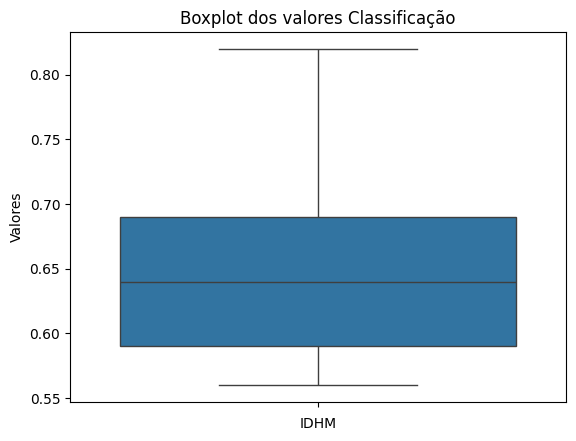

In [75]:
# Usando o seanbotn para gráfico de boxplot
sns.boxplot(y = df_idhm_estado['idhm'], data = df_idhm_estado)

# Adicionar título e rotulos para eixos
plt.title('Boxplot dos valores Classificação')
plt.xlabel('IDHM')
plt.ylabel('Valores');


### Criar uma gráfico de barra

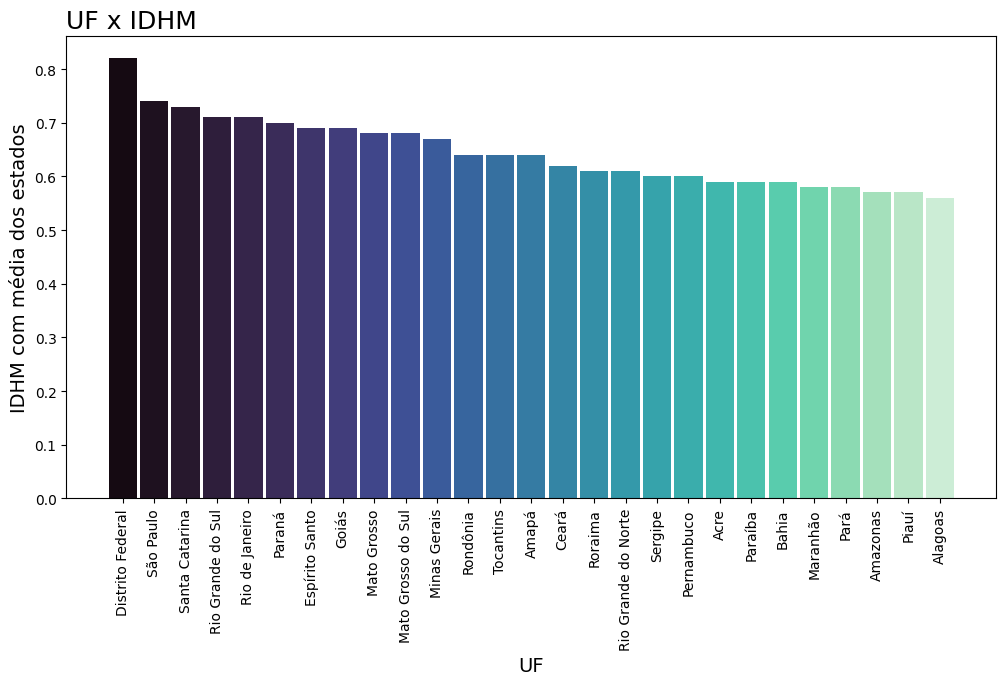

In [76]:
df_idhm_estado = df_idhm_estado.sort_values(by='idhm', ascending=False)

# Tamanho Figura
plt.figure(figsize=(12, 6))

# Paleta de cores
paleta_cores = sns.color_palette('mako', len(df_idhm_estado))

# Plotagem
plt.bar(df_idhm_estado['uf'],
        df_idhm_estado['idhm'],
        width=0.9,
        color=paleta_cores
        )

# Titulo
plt.title('UF x IDHM', loc= 'left', fontsize=18)


# Labels
plt.xlabel('UF', fontsize=14)
plt.ylabel('IDHM com média dos estados', fontsize=14)
plt.xticks(rotation = 90);

In [77]:
df_idhm_estado.head(10)

,uf,idhm,classe
6,Distrito Federal,0.82,Alto desenvolvimento Humano
25,São Paulo,0.74,Médio desenvolvimento Humano
23,Santa Catarina,0.73,Médio desenvolvimento Humano
19,Rio Grande do Sul,0.71,Médio desenvolvimento Humano
20,Rio de Janeiro,0.71,Médio desenvolvimento Humano
13,Paraná,0.70,Médio desenvolvimento Humano
7,Espírito Santo,0.69,Médio desenvolvimento Humano
8,Goiás,0.69,Médio desenvolvimento Humano
10,Mato Grosso,0.68,Médio desenvolvimento Humano
11,Mato Grosso do Sul,0.68,Médio desenvolvimento Humano


In [78]:
# Criar um gráfico de barras uusando o plotly

fig = px.bar(df_idhm_estado,
             x='uf',
             y='idhm',
             color='classe',
             title= 'IDHM por Estado',
             color_discrete_sequence=[ 'green', 'orange']
);

fig.show()

In [79]:
# Usando plotly para Treemap

fig = px.treemap(df_idhm_estado,
                 path=['uf'],
                 values='idhm',
);

fig.show()

In [80]:
#Filtro
df_idhm_eestado = pd.DataFrame(df_idhm.groupby('uf')[['idhm', 'idhm_educacao', 'idhm_longevidade', 'idhm_renda']].mean().round(2)).reset_index()

In [81]:
df_idhm_eestado

,uf,idhm,idhm_educacao,idhm_longevidade,idhm_renda
0,Acre,0.59,0.45,0.77,0.59
1,Alagoas,0.56,0.44,0.74,0.55
2,Amapá,0.64,0.55,0.78,0.62
3,Amazonas,0.57,0.44,0.77,0.55
4,Bahia,0.59,0.48,0.76,0.57
5,Ceará,0.62,0.55,0.76,0.56
6,Distrito Federal,0.82,0.74,0.87,0.86
7,Espírito Santo,0.69,0.59,0.83,0.68
8,Goiás,0.69,0.60,0.83,0.68
9,Maranhão,0.58,0.49,0.74,0.53
